In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

1)Data Load

In [2]:
df= pd.read_csv(r"C:\Users\Lenovo\Downloads\train(1).csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
df.shape

(891, 12)

In [5]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [6]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
y = df["Survived"]
X = df.drop("Survived", axis=1)

2)preprocessing

In [9]:
X = X.drop(["PassengerId", "Name", "Ticket", "Cabin"], axis=1)

In [10]:
X["Age"] = X["Age"].fillna(X["Age"].median())

In [11]:
X["Embarked"] = X["Embarked"].fillna(X["Embarked"].mode()[0])

In [12]:
X = pd.get_dummies(X, columns=["Sex","Embarked"], drop_first=True)

3)train

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
from sklearn.preprocessing import StandardScaler

In [16]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

4)models

In [17]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)
y_pred_lr= regressor.predict(X_test)

In [18]:
from sklearn.svm import SVC
svm = SVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

In [20]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

5)evaluation

In [23]:
y_test = y_test.astype(int)
y_pred_lr = y_pred_lr.astype(int)
y_pred_svm = y_pred_svm.astype(int)
y_pred_knn = y_pred_knn.astype(int)

In [24]:
from sklearn.metrics import classification_report, confusion_matrix
print("Logistic Regression:")
print(classification_report(y_test, y_pred_lr, zero_division=0))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr), "\n")

print("SVM:")
print(classification_report(y_test, y_pred_svm, zero_division=0))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm), "\n")

print("KNN:")
print(classification_report(y_test, y_pred_knn, zero_division=0))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))

Logistic Regression:
              precision    recall  f1-score   support

           0       0.61      1.00      0.76       105
           1       1.00      0.09      0.17        74

    accuracy                           0.63       179
   macro avg       0.81      0.55      0.47       179
weighted avg       0.77      0.63      0.52       179

Confusion Matrix:
 [[105   0]
 [ 67   7]] 

SVM:
              precision    recall  f1-score   support

           0       0.81      0.90      0.86       105
           1       0.84      0.70      0.76        74

    accuracy                           0.82       179
   macro avg       0.83      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179

Confusion Matrix:
 [[95 10]
 [22 52]] 

KNN:
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg 

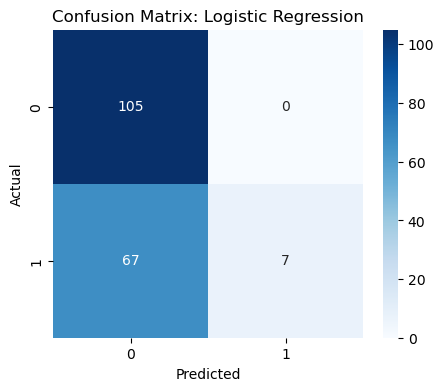

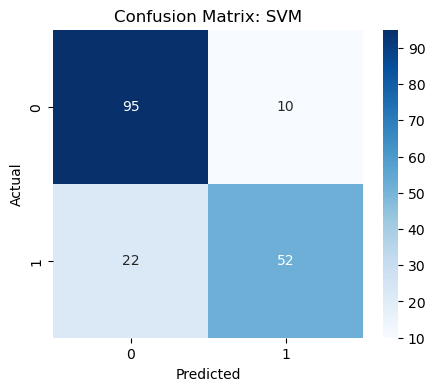

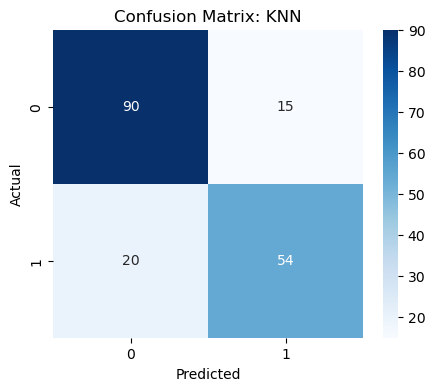

In [25]:
from sklearn.metrics import confusion_matrix

def plot_confusion(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix: {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_confusion(y_test, y_pred_lr, "Logistic Regression")
plot_confusion(y_test, y_pred_svm, "SVM")
plot_confusion(y_test, y_pred_knn, "KNN")